In [ ]:
import pandas as pd
from rdkit.Chem import PandasTools
from rdkit.Chem.rdmolfiles import MolToSmiles, SDMolSupplier
from rich.progress import track

In [16]:
file = "/homes/buttensc/Network/Projects/3d_mol_gen_benchmark/data/01_raw/drugbank_approved_3d.sdf"
df = PandasTools.LoadSDF(file, smilesName="smiles", molColName="mol", includeFingerprints=True)

In [35]:
df.head(3)

,DATABASE_ID,DATABASE_NAME,ORIGINAL_SOURCE,ORIGINAL_SOURCE_URL,SMILES,INCHI_IDENTIFIER,INCHI_KEY,FORMULA,MOLECULAR_WEIGHT,EXACT_MASS,...,SECONDARY_ACCESSION_NUMBERS,DRUG_GROUPS,GENERIC_NAME,SYNONYMS,PRODUCTS,INTERNATIONAL_BRANDS,SALTS,ID,smiles,mol
0,DB00114,drugbank,PUBCHEM,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,CC1=NC=C(COP(O)(O)=O)C(C=O)=C1O,InChI=1S/C8H10NO6P/c1-5-8(11)7(3-10)6(2-9-5)4-...,NGVDGCNFYWLIFO-UHFFFAOYSA-N,C8H10NO6P,247.1419,247.024573569,...,NUTR00045,approved; investigational; nutraceutical,Pyridoxal phosphate,3-hydroxy-2-methyl-5-((phosphonooxy)methyl)-4-...,Amladex; Azesco; BumP DHA; Dexivite; Dyzbac; E...,Biosechs; Himitan; Vitazechs,Pyridoxal phosphate hydrate,1051,Cc1ncc(COP(=O)(O)O)c(C=O)c1O,<rdkit.Chem.rdchem.Mol object at 0x7f553c1da880>
1,DB00118,drugbank,PUBCHEM,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,C[S+](CC[C@H](N)C([O-])=O)C[C@H]1O[C@H]([C@H](...,InChI=1S/C15H22N6O5S/c1-27(3-2-7(16)15(24)25)4...,MEFKEPWMEQBLKI-AIRLBKTGSA-N,C15H22N6O5S,398.44,398.137239006,...,NUTR00052,approved; investigational; nutraceutical,Ademetionine,Ademetionine; AdoMet; L-S-Adenosylmethionine; ...,NaN,Donamet; Sam-Sulfate; SAMe; SAMe Rx-Mood,Ademetionine butanedisulfonate; Ademetionine d...,34755,C[S@@+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2c...,<rdkit.Chem.rdchem.Mol object at 0x7f553c1daa40>
2,DB00119,drugbank,PUBCHEM,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,CC(=O)C(O)=O,"InChI=1S/C3H4O3/c1-2(4)3(5)6/h1H3,(H,5,6)",LCTONWCANYUPML-UHFFFAOYSA-N,C3H4O3,88.0621,88.016043994,...,NUTR00050; DB11194,approved; investigational; nutraceutical,Pyruvic acid,2-ketopropionic acid; 2-oxopropanoic acid; 2-O...,Rejuvesol,NaN,Calcium pyruvate; Methylselenopyruvate; Sodium...,1060,CC(=O)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7f553c1dace0>


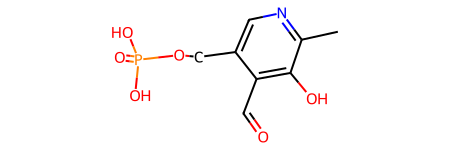

In [32]:
df["mol"][0]

In [41]:
df_dubs = df[df["smiles"].duplicated(keep=False)].sort_values(["smiles", "DATABASE_ID"]).set_index("DATABASE_ID")

,SMILES,smiles,GENERIC_NAME,mol
DATABASE_ID,,,,
DB00825,CC(C)[C@@H]1CC[C@@H](C)C[C@H]1O,CC(C)[C@@H]1CC[C@@H](C)C[C@H]1O,Levomenthol,
DB14123,CC(C)C1CCC(C)CC1O,CC(C)[C@@H]1CC[C@@H](C)C[C@H]1O,Menthol,
DB01744,[H][C@@]12CC[C@@](C)(C(=O)C1)C2(C)C,CC1(C)[C@@H]2CC[C@@]1(C)C(=O)C2,Camphor,
DB14156,CC1(C)C2CCC1(C)C(=O)C2,CC1(C)[C@@H]2CC[C@@]1(C)C(=O)C2,Synthetic camphor,
DB00297,CCCCN1CCCCC1C(=O)NC1=C(C)C=CC=C1C,CCCCN1CCCC[C@H]1C(=O)Nc1c(C)cccc1C,Bupivacaine,
DB01002,CCCCN1CCCC[C@H]1C(=O)NC1=C(C)C=CC=C1C,CCCCN1CCCC[C@H]1C(=O)Nc1c(C)cccc1C,Levobupivacaine,
DB00215,CN(C)CCCC1(OCC2=C1C=CC(=C2)C#N)C1=CC=C(F)C=C1,CN(C)CCC[C@@]1(c2ccc(F)cc2)OCc2cc(C#N)ccc21,Citalopram,
DB01175,CN(C)CCC[C@]1(OCC2=C1C=CC(=C2)C#N)C1=CC=C(F)C=C1,CN(C)CCC[C@@]1(c2ccc(F)cc2)OCc2cc(C#N)ccc21,Escitalopram,
DB00405,CN(C)CC[C@@H](C1=CC=C(Br)C=C1)C1=CC=CC=N1,CN(C)CC[C@@H](c1ccc(Br)cc1)c1ccccn1,Dexbrompheniramine,

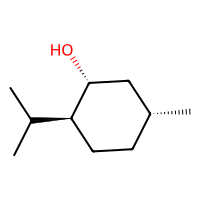
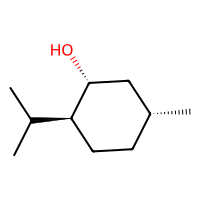
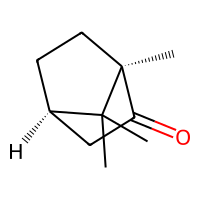
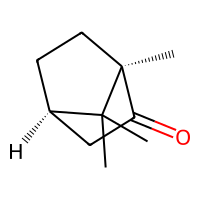
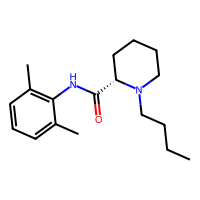
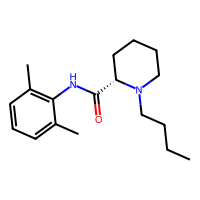
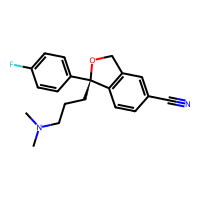
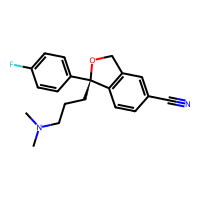
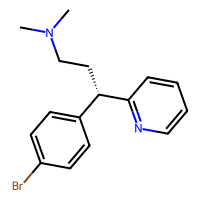
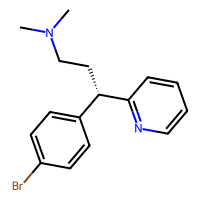
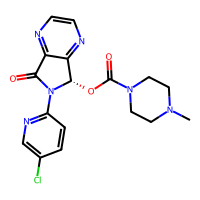
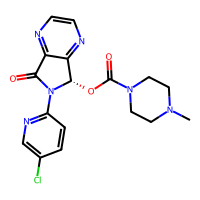
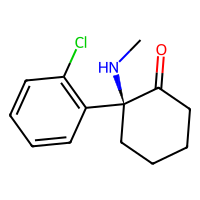
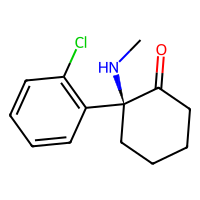
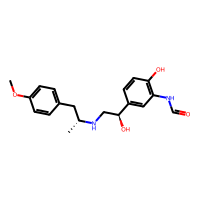
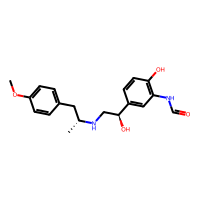
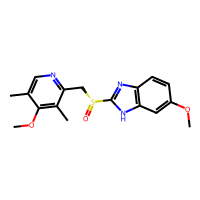
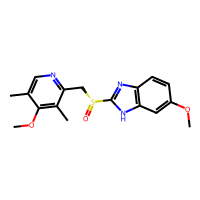
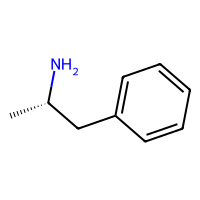
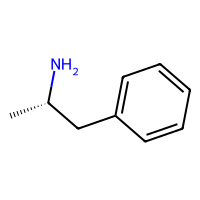
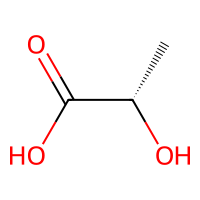
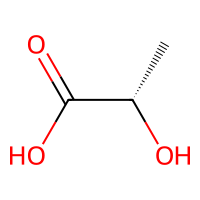
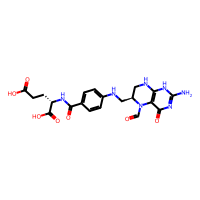
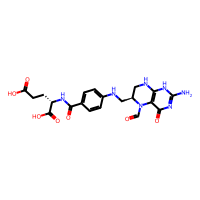

In [44]:
df_dubs = df_dubs[["SMILES", "smiles", "GENERIC_NAME", "mol"]]
df_dubs["mol"].apply(lambda m: m.RemoveAllConformers())
PandasTools.ChangeMoleculeRendering(frame=df_dubs)
df_dubs